
=== Running experiment: baseline ===
[baseline] Tuning Classification Models (Threshold: 20)...
[baseline] Fold 1 complete.
[baseline] Fold 2 complete.
[baseline] Fold 3 complete.
[baseline] Fold 4 complete.
[baseline] Fold 5 complete.


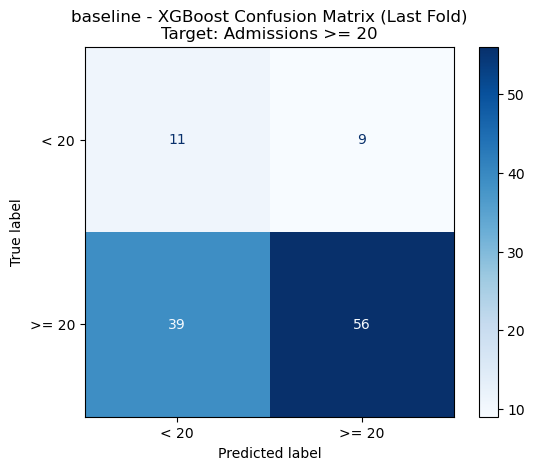


=== Running experiment: drop_temp_group ===
[drop_temp_group] Tuning Classification Models (Threshold: 20)...
[drop_temp_group] Fold 1 complete.
[drop_temp_group] Fold 2 complete.
[drop_temp_group] Fold 3 complete.
[drop_temp_group] Fold 4 complete.
[drop_temp_group] Fold 5 complete.


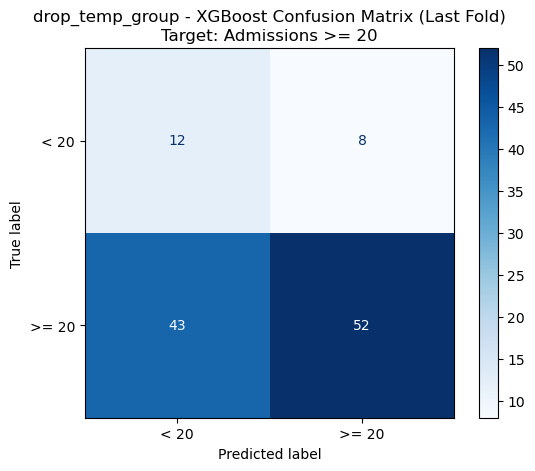


=== Running experiment: drop_nox_only ===
[drop_nox_only] Tuning Classification Models (Threshold: 20)...
[drop_nox_only] Fold 1 complete.
[drop_nox_only] Fold 2 complete.
[drop_nox_only] Fold 3 complete.
[drop_nox_only] Fold 4 complete.
[drop_nox_only] Fold 5 complete.


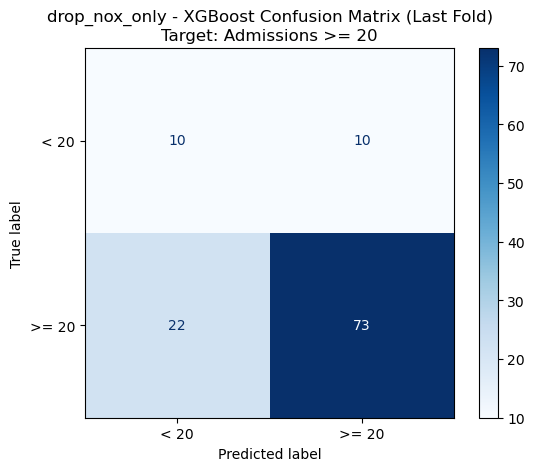


=== Running experiment: drop_no_only ===
[drop_no_only] Tuning Classification Models (Threshold: 20)...
[drop_no_only] Fold 1 complete.
[drop_no_only] Fold 2 complete.
[drop_no_only] Fold 3 complete.
[drop_no_only] Fold 4 complete.
[drop_no_only] Fold 5 complete.


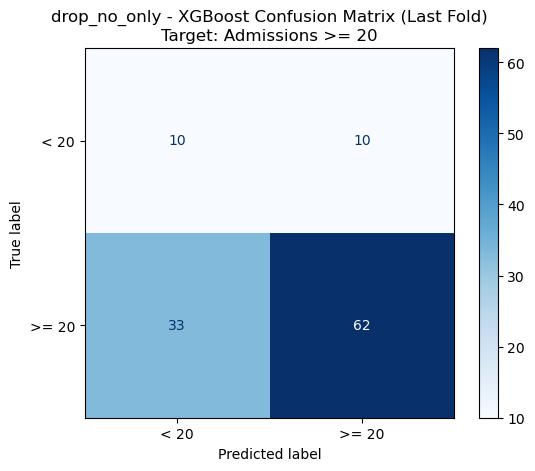


=== Running experiment: drop_voc_group (Benzene + Toluene) ===
[drop_voc_group (Benzene + Toluene)] Tuning Classification Models (Threshold: 20)...
[drop_voc_group (Benzene + Toluene)] Fold 1 complete.
[drop_voc_group (Benzene + Toluene)] Fold 2 complete.
[drop_voc_group (Benzene + Toluene)] Fold 3 complete.
[drop_voc_group (Benzene + Toluene)] Fold 4 complete.
[drop_voc_group (Benzene + Toluene)] Fold 5 complete.


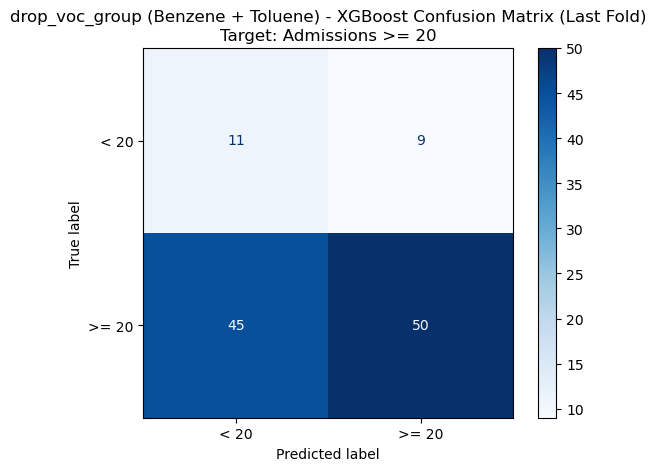


=== Running experiment: drop_index_windgust ===
[drop_index_windgust] Tuning Classification Models (Threshold: 20)...
[drop_index_windgust] Fold 1 complete.
[drop_index_windgust] Fold 2 complete.
[drop_index_windgust] Fold 3 complete.
[drop_index_windgust] Fold 4 complete.
[drop_index_windgust] Fold 5 complete.


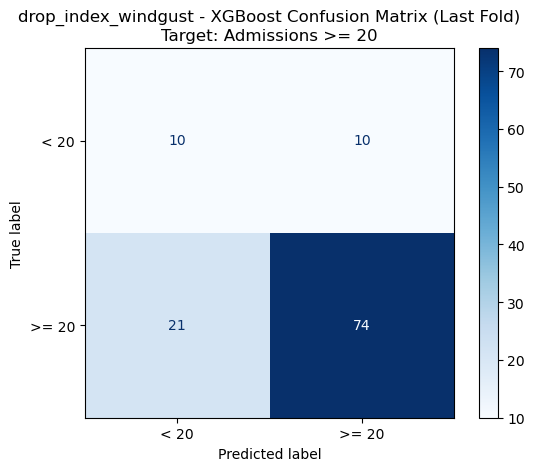


=== Running experiment: drop_humidity ===
[drop_humidity] Tuning Classification Models (Threshold: 20)...
[drop_humidity] Fold 1 complete.
[drop_humidity] Fold 2 complete.
[drop_humidity] Fold 3 complete.
[drop_humidity] Fold 4 complete.
[drop_humidity] Fold 5 complete.


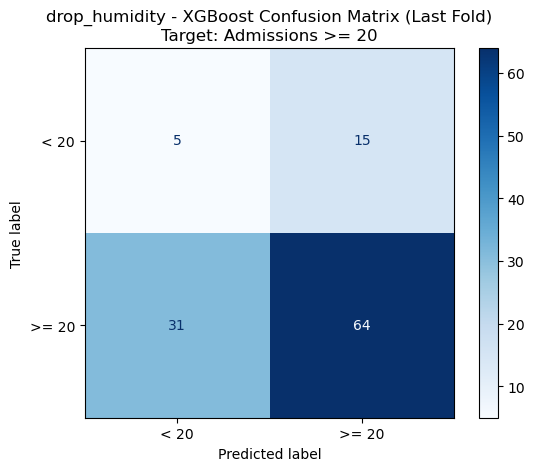


=== Experiment comparison (mean CV metrics) ===
                           experiment  Dummy_Baseline_Accuracy  \
0                            baseline                 0.558261   
1                     drop_temp_group                 0.558261   
2                       drop_nox_only                 0.558261   
3                        drop_no_only                 0.558261   
4  drop_voc_group (Benzene + Toluene)                 0.558261   
5                 drop_index_windgust                 0.558261   
6                       drop_humidity                 0.558261   

   Dummy_Baseline_F1  Dummy_Baseline_AUC  LogisticRegression_Accuracy  \
0           0.603605                 0.5                     0.549565   
1           0.603605                 0.5                     0.608696   
2           0.603605                 0.5                     0.509565   
3           0.603605                 0.5                     0.572174   
4           0.603605                 0.5                 

In [5]:
import os
import numpy as np
import pandas as pd
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- CONFIGURATION ---
THRESHOLD = 20
LAG_DAYS = [1, 3, 7]
ROLL_WINDOWS = [3, 7]
TARGET_COL = "Number of Admissions"
WIND_DIR_COL = "wind_direction_10m_dominant (°)"
N_SPLITS = 5
N_TRIALS = 25
RANDOM_STATE = 42


# --- 1. FEATURE ENGINEERING ---
def engineer_features(df):
    df = df.copy()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)

    # Cyclical Seasonality
    df["dow_sin"] = np.sin(2 * np.pi * df['Timestamp'].dt.dayofweek / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df['Timestamp'].dt.dayofweek / 7)
    df["month_sin"] = np.sin(2 * np.pi * df['Timestamp'].dt.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df['Timestamp'].dt.month / 12)
    # Regime indicators for seasonality and trend
    df["month_regime"] = df['Timestamp'].dt.month
    years = df['Timestamp'].dt.year
    year_order = {year: i + 1 for i, year in enumerate(sorted(years.unique()))}
    df["year_regime"] = years.map(year_order)
    df["weekend"] = (df['Timestamp'].dt.dayofweek >= 5).astype(int)

    if WIND_DIR_COL in df.columns:
        df["wind_sin"] = np.sin(2 * np.pi * df[WIND_DIR_COL] / 360)
        df["wind_cos"] = np.cos(2 * np.pi * df[WIND_DIR_COL] / 360)

    exclude = ['Timestamp', TARGET_COL, WIND_DIR_COL, 'Date']
    weather_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

    new_feats = {}
    for col in weather_cols:
        for lag in LAG_DAYS:
            new_feats[f"{col}_lag{lag}"] = df[col].shift(lag)
        for roll in ROLL_WINDOWS:
            new_feats[f"{col}_roll{roll}"] = df[col].shift(1).rolling(roll).mean()

    new_feats["admission_lag7"] = df[TARGET_COL].shift(7)

    df = pd.concat([df, pd.DataFrame(new_feats)], axis=1).dropna().reset_index(drop=True)
    df['target_binary'] = (df[TARGET_COL] >= THRESHOLD).astype(int)
    return df


# --- 2. TUNING LOGIC ---
def get_optuna_params(model_type, X_tr, y_tr, X_va, y_va):
    def objective(trial):
        if model_type == 'rf':
            p = {
                'n_estimators': trial.suggest_int("n_estimators", 50, 200),
                'max_depth': trial.suggest_int("max_depth", 5, 20),
            }
            model = RandomForestClassifier(**p, random_state=RANDOM_STATE, n_jobs=-1)
        elif model_type == 'xgb':
            p = {
                'n_estimators': trial.suggest_int("n_estimators", 50, 300),
                'max_depth': trial.suggest_int("max_depth", 3, 10),
                'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            }
            model = xgb.XGBClassifier(**p, random_state=RANDOM_STATE, eval_metric='logloss')

        model.fit(X_tr, y_tr)
        return f1_score(y_va, model.predict(X_va))

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)
    return study.best_params


# --- 3. DATA LOADING & MERGE (WITH HUMIDITY) ---
def load_merged_data():
    base_df = pd.read_csv("/Users/suhaniagarwal/Downloads/all_features_data.csv")

    extra_weather = pd.read_csv(
        "/Users/suhaniagarwal/Downloads/extra_weather_variables (csv).csv",
        skiprows=3,
        header=0,
    )

    # Keep only the date and the chosen humidity column
    humidity_cols = ["time", "relative_humidity_2m_mean (%)"]
    extra_humidity = extra_weather[humidity_cols].copy()

    # Align date types for merge
    base_df["Timestamp"] = pd.to_datetime(base_df["Timestamp"])
    extra_humidity["time"] = pd.to_datetime(extra_humidity["time"])

    merged = base_df.merge(
        extra_humidity,
        left_on="Timestamp",
        right_on="time",
        how="left",
    )

    # Drop the redundant merge key from extra_weather
    merged = merged.drop(columns=["time"])

    return merged


# --- 4. EXPERIMENT RUNNER ---
def run_experiment(df, experiment_name, drop_cols=None):
    """
    Run the full time-series CV + Optuna-tuned pipeline on a given DataFrame.
    Optionally drop a list of base columns before feature engineering.
    Returns a one-row DataFrame of mean metrics with an 'experiment' column.
    """
    df_local = df.copy()

    # Drop specified base columns (if they exist) before feature engineering
    if drop_cols:
        existing = [c for c in drop_cols if c in df_local.columns]
        if existing:
            df_local = df_local.drop(columns=existing)

    df_fe = engineer_features(df_local)
    feat_cols = [
        c
        for c in df_fe.columns
        if any(s in c for s in ["_lag", "_roll", "sin", "cos", "weekend", "regime"])
    ]
    X, y = df_fe[feat_cols], df_fe["target_binary"]

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_results = []
    best_params = {}

    last_y_test, last_y_preds = None, None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = RobustScaler()
        X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

        if fold == 0:
            print(f"[{experiment_name}] Tuning Classification Models (Threshold: {THRESHOLD})...")
            split = int(len(X_train_s) * 0.8)
            for m in ["rf", "xgb"]:
                best_params[m] = get_optuna_params(
                    m,
                    X_train_s[:split],
                    y_train.iloc[:split],
                    X_train_s[split:],
                    y_train.iloc[split:],
                )

        models = {
            "Dummy_Baseline": DummyClassifier(strategy="most_frequent"),
            "LogisticRegression": LogisticRegressionCV(cv=5),
            "RandomForest": RandomForestClassifier(**best_params["rf"]),
            "XGBoost": xgb.XGBClassifier(**best_params["xgb"]),
            "SVM": SVC(probability=True),
        }

        scores = {}
        for name, model in models.items():
            model.fit(X_train_s, y_train)
            preds = model.predict(X_test_s)

            scores[f"{name}_Accuracy"] = accuracy_score(y_test, preds)
            scores[f"{name}_F1"] = f1_score(y_test, preds)

            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(X_test_s)[:, 1]
                scores[f"{name}_AUC"] = roc_auc_score(y_test, probs)

            if fold == N_SPLITS - 1 and name == "XGBoost":
                last_y_test = y_test
                last_y_preds = preds

        fold_results.append(scores)
        print(f"[{experiment_name}] Fold {fold+1} complete.")

    # Summarise metrics across folds
    metrics_mean = pd.DataFrame(fold_results).mean().to_frame().T
    metrics_mean.insert(0, "experiment", experiment_name)

    # Optionally show confusion matrix for the last fold's XGBoost
    if last_y_test is not None and last_y_preds is not None:
        cm = confusion_matrix(last_y_test, last_y_preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[f"< {THRESHOLD}", f">= {THRESHOLD}"],
        )
        disp.plot(cmap=plt.cm.Blues)
        plt.title(
            f"{experiment_name} - XGBoost Confusion Matrix (Last Fold)\n"
            f"Target: Admissions >= {THRESHOLD}"
        )
        plt.show()

    return metrics_mean


# --- 5. EXPERIMENT DEFINITIONS & ENTRYPOINT ---
EXPERIMENTS = {
    "baseline": [],
    "drop_temp_group": [
        "temperature_2m_max (°C)",
        "temperature_2m_min (°C)",
        "apparent_temperature_mean (°C)",
        "apparent_temperature_max (°C)",
        "apparent_temperature_min (°C)",
    ],
    "drop_nox_only": [
        "NOx (ppb)",
    ],
    "drop_no_only": [
        "NO (µg/m³)",
    ],
    "drop_voc_group (Benzene + Toluene)": [
        "Benzene (µg/m³)",
        "Toluene (µg/m³)",
    ],
    "drop_index_windgust": [
        "Index Value",
        "wind_gusts_10m_max (km/h)",
    ],
    "drop_humidity": [
        "relative_humidity_2m_mean (%)",
    ],
}


def run_all_experiments():
    """
    Load the merged dataset once and run all defined experiments.
    Returns a DataFrame comparing mean CV metrics per experiment.
    """
    merged = load_merged_data()
    results = []

    for name, drop_cols in EXPERIMENTS.items():
        print(f"\n=== Running experiment: {name} ===")
        metrics = run_experiment(merged, name, drop_cols)
        results.append(metrics)

    comparison = pd.concat(results, ignore_index=True)
    print("\n=== Experiment comparison (mean CV metrics) ===")
    print(comparison)
    return comparison


if __name__ == "__main__":
    run_all_experiments()